### Now we evaluate ALL models together:

* Linear Regression
* Random Forest
* Gradient Boosting
* LSTM

using:

* RMSE
* MAE
* R² Score

and then compare them.

### STEP 1 — Import Evaluation Libraries

In [5]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import matplotlib.pyplot as plt

### STEP 2 — Load Prediction Files

In [6]:
lr_df = pd.read_csv(
    "stock_datasets/lr_predictions.csv"
)

rf_df = pd.read_csv(
    "stock_datasets/rf_predictions.csv"
)

gb_df = pd.read_csv(
    "stock_datasets/gb_predictions.csv"
)

lstm_df = pd.read_csv(
    "stock_datasets/lstm_predictions.csv"
)

### STEP 3 — Extract Actual and Predicted Values

In [9]:
## Linear Regression
y_test_lr = lr_df["Actual"]

y_pred_lr = lr_df["Predicted"]

In [10]:
## Random Forest
y_test_rf = rf_df["Actual"]

y_pred_rf = rf_df["Predicted"]

In [11]:
## Gradient Boosting
y_test_gb = gb_df["Actual"]

y_pred_gb = gb_df["Predicted"]

In [13]:
## LSTM
y_test_lstm = lstm_df["Actual"]

y_pred_lstm = lstm_df["Predicted"]

### STEP 4 — Evaluate Linear Regression

In [14]:
rmse_lr = np.sqrt(
    mean_squared_error(
        y_test_lr,
        y_pred_lr
    )
)

mae_lr = mean_absolute_error(
    y_test_lr,
    y_pred_lr
)

r2_lr = r2_score(
    y_test_lr,
    y_pred_lr
)

print("Linear Regression")
print("RMSE:", rmse_lr)
print("MAE :", mae_lr)
print("R2  :", r2_lr)

Linear Regression
RMSE: 19.36003207436621
MAE : 13.988612510151365
R2  : 0.9611508062713986


### STEP 5 — Evaluate Random Forest

In [15]:
rmse_rf = np.sqrt(
    mean_squared_error(
        y_test_rf,
        y_pred_rf
    )
)

mae_rf = mean_absolute_error(
    y_test_rf,
    y_pred_rf
)

r2_rf = r2_score(
    y_test_rf,
    y_pred_rf
)

print("Random Forest")
print("RMSE:", rmse_rf)
print("MAE :", mae_rf)
print("R2  :", r2_rf)

Random Forest
RMSE: 105.45014357695183
MAE : 84.99684794627836
R2  : -0.15256178498612294


### STEP 6 — Evaluate Gradient Boosting

In [16]:
rmse_gb = np.sqrt(
    mean_squared_error(
        y_test_gb,
        y_pred_gb
    )
)

mae_gb = mean_absolute_error(
    y_test_gb,
    y_pred_gb
)

r2_gb = r2_score(
    y_test_gb,
    y_pred_gb
)

print("Gradient Boosting")
print("RMSE:", rmse_gb)
print("MAE :", mae_gb)
print("R2  :", r2_gb)

Gradient Boosting
RMSE: 109.39268020142669
MAE : 88.94602991817769
R2  : -0.24035611183224548


### STEP 7 — Evaluate LSTM

In [17]:
rmse_lstm = np.sqrt(
    mean_squared_error(
        y_test_lstm,
        y_pred_lstm
    )
)

mae_lstm = mean_absolute_error(
    y_test_lstm,
    y_pred_lstm
)

r2_lstm = r2_score(
    y_test_lstm,
    y_pred_lstm
)

print("LSTM")
print("RMSE:", rmse_lstm)
print("MAE :", mae_lstm)
print("R2  :", r2_lstm)

LSTM
RMSE: 0.025792657273627347
MAE : 0.020873237303424205
R2  : 0.8615754344738311


In [30]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# Reload original close prices
lstm_df = pd.read_csv(
    "stock_datasets/RELIANCE_lstm_unscaled.csv"
)

# Recreate scaler
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(
    lstm_df[["Close"]]
)

# Inverse transform
y_test_actual = scaler.inverse_transform(y_test_lstm.values.reshape(-1, 1))

y_pred_actual = scaler.inverse_transform(y_pred_lstm.values.reshape(-1, 1))

In [31]:
rmse_lstm = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_actual
    )
)

### STEP 8 — Create Comparison Table

In [32]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "LSTM"
    ],

    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_gb,
        rmse_lstm
    ],

    "MAE": [
        mae_lr,
        mae_rf,
        mae_gb,
        mae_lstm
    ],

    "R2 Score": [
        r2_lr,
        r2_rf,
        r2_gb,
        r2_lstm
    ]
})

print(results)

               Model        RMSE        MAE  R2 Score
0  Linear Regression   19.360032  13.988613  0.961151
1      Random Forest  105.450144  84.996848 -0.152562
2  Gradient Boosting  109.392680  88.946030 -0.240356
3               LSTM   36.594864   0.020873  0.861575


### STEP 9 — Save Evaluation Results

In [33]:
results.to_csv(
    "stock_datasets/model_evaluation_results.csv",
    index=False
)

### STEP 10 — RMSE Comparison Plot

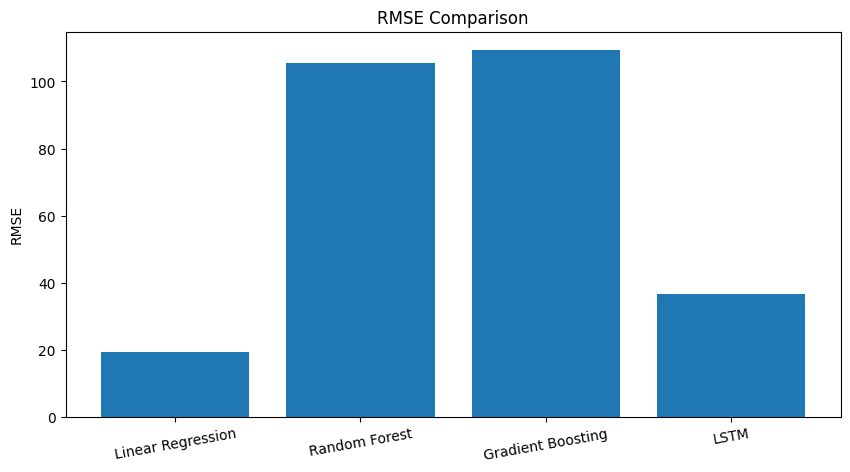

In [34]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title("RMSE Comparison")

plt.ylabel("RMSE")

plt.xticks(rotation=10)

plt.show()

### STEP 11 — MAE Comparison Plot

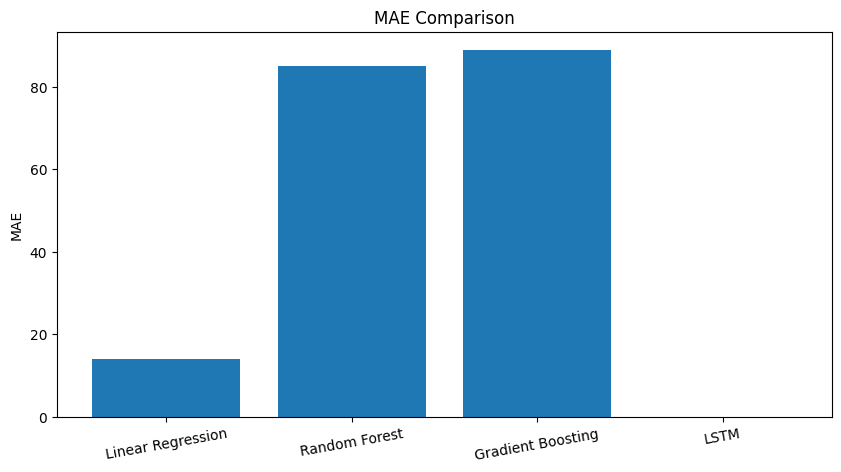

In [35]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["MAE"]
)

plt.title("MAE Comparison")

plt.ylabel("MAE")

plt.xticks(rotation=10)

plt.show()

### STEP 12 — R² Score Comparison Plot

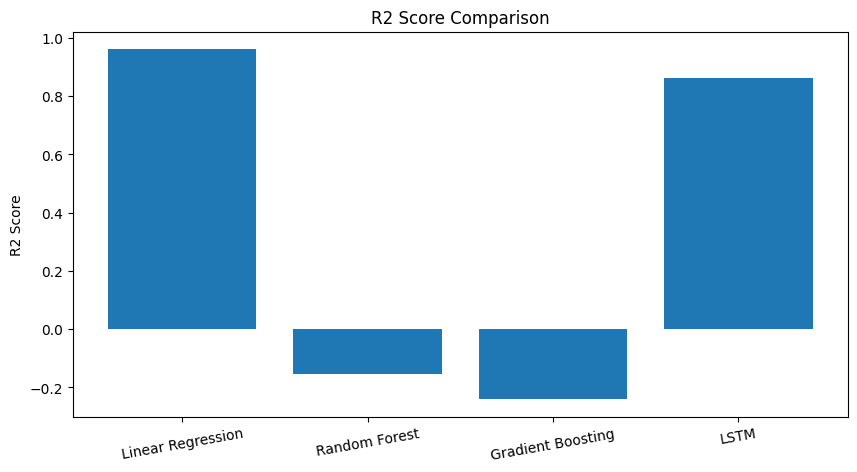

In [36]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["R2 Score"]
)

plt.title("R2 Score Comparison")

plt.ylabel("R2 Score")

plt.xticks(rotation=10)

plt.show()

### STEP 13 — Actual vs Predicted Plot

#### Linear Regression Plot

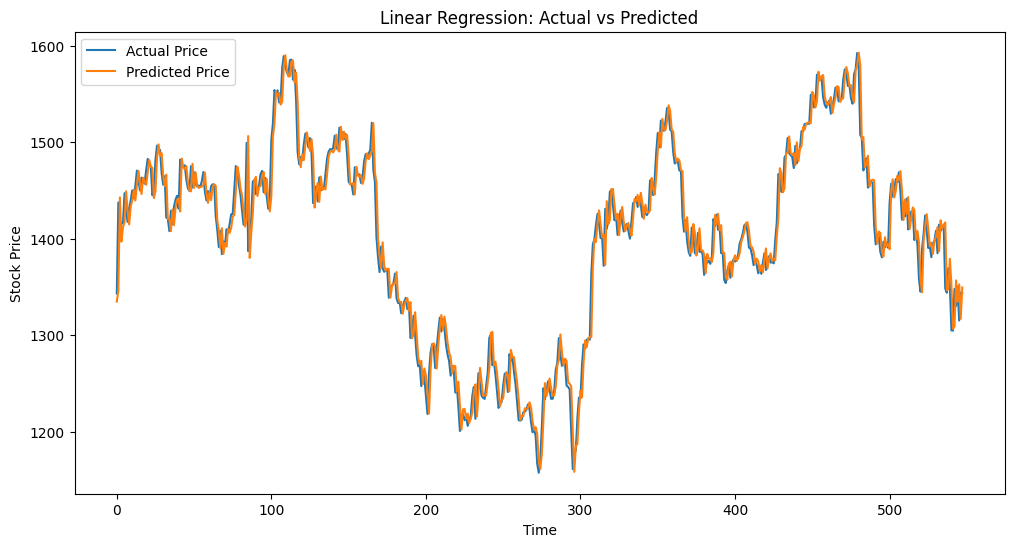

In [37]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test_lr.values,
    label="Actual Price"
)

plt.plot(
    y_pred_lr.values,
    label="Predicted Price"
)

plt.title("Linear Regression: Actual vs Predicted")

plt.xlabel("Time")

plt.ylabel("Stock Price")

plt.legend()

plt.show()

#### Random Forest Plot

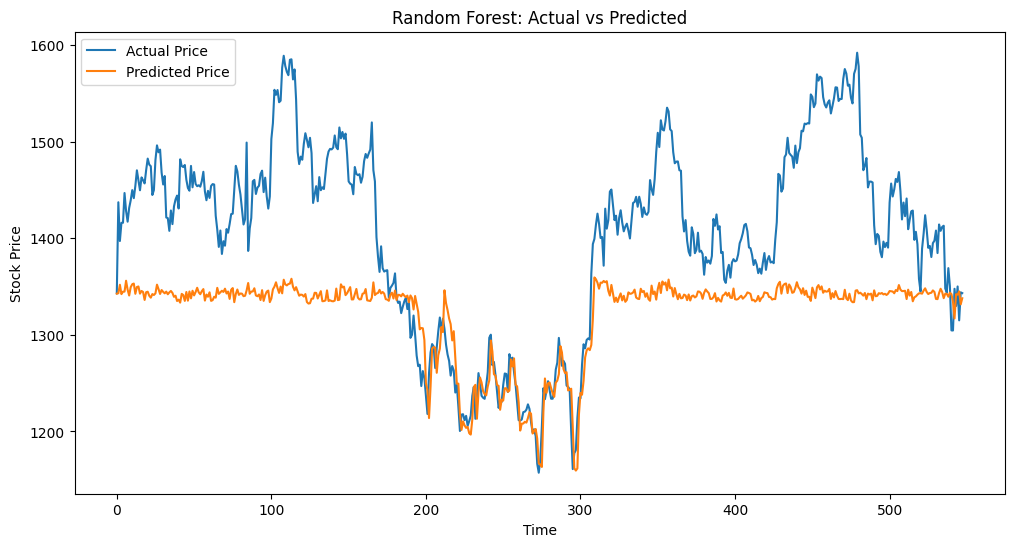

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test_rf.values,
    label="Actual Price"
)

plt.plot(
    y_pred_rf.values,
    label="Predicted Price"
)

plt.title("Random Forest: Actual vs Predicted")

plt.xlabel("Time")

plt.ylabel("Stock Price")

plt.legend()

plt.show()

#### Gradient Boosting Plot

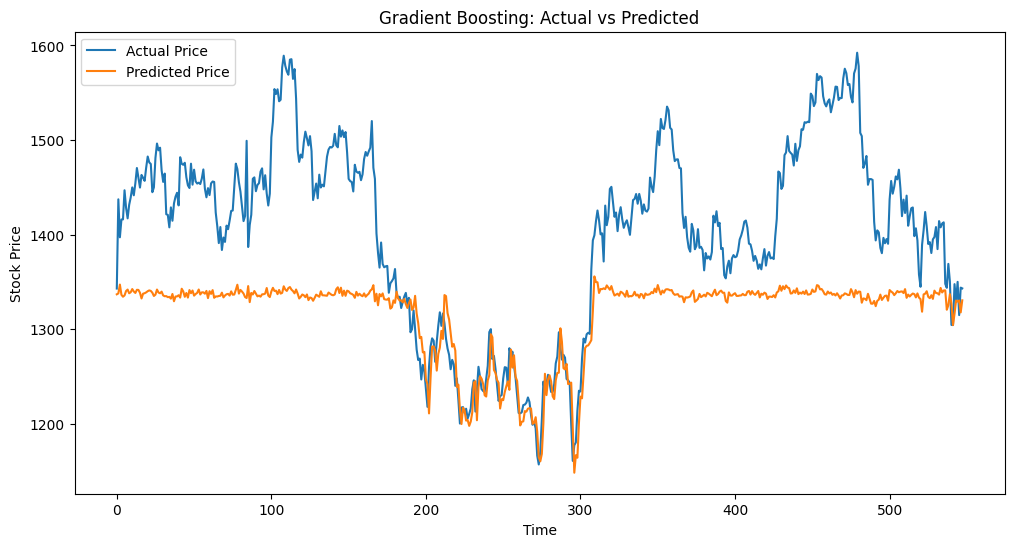

In [39]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test_gb.values,
    label="Actual Price"
)

plt.plot(
    y_pred_gb.values,
    label="Predicted Price"
)

plt.title("Gradient Boosting: Actual vs Predicted")

plt.xlabel("Time")

plt.ylabel("Stock Price")

plt.legend()

plt.show()

#### LSTM

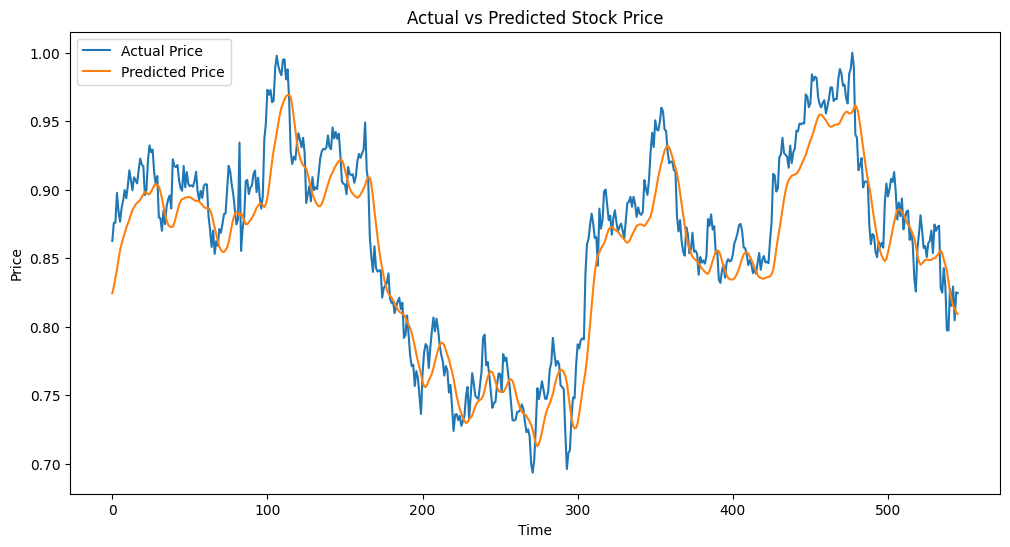

In [40]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test_lstm.values,
    label="Actual Price"
)

plt.plot(
    y_pred_lstm.values,
    label="Predicted Price"
)

plt.title("Actual vs Predicted Stock Price")

plt.xlabel("Time")

plt.ylabel("Price")

plt.legend()

plt.show()